In [17]:
import pandas as pd
import json

# Load dataset
df = pd.read_csv("haunted_places_v2.tsv", sep="\t")

# Preview columns
df.columns

Index(['city', 'country', 'description', 'location', 'state', 'state_abbrev',
       'longitude', 'latitude', 'city_longitude', 'city_latitude',
       'Audio Evidence', 'Image/Video/Visual Evidence', 'Haunted Places Date',
       'Haunted Places Witness Count', 'Time of Day', 'Apparition Type',
       'Ghost Category', 'Event Type',
       'Over 18 binge drink at least once per month',
       'Alcohol deaths per capita',
       'Annual deaths attributable to excessive alcohol use', 'Sunrise',
       'Sunset', 'Daylight Duration', 'Daylight Duration 2', 'crime_solved',
       'victim_sex', 'weapon', 'Median Age', 'Population', 'Housing Units',
       'moon_phase', 'moon_diameter', 'moon_distance'],
      dtype='object')

In [18]:
# Load dataset
df = pd.read_csv("haunted_places_v2.tsv", sep="\t")

# Subset only 'location' and 'Haunted Places Date'
subset = df[['location', 'Haunted Places Date']]

# Save subset as JSON (Task 1 output)
subset_json = subset.to_dict(orient="records")

with open("subset_data.json", "w") as f:
    json.dump(subset_json, f, indent=2)

print("subset_data.json created from 'location' and 'Haunted Places Date'")

subset_data.json created from 'location' and 'Haunted Places Date'


In [19]:
# Convert Haunted Places Date to datetime
subset['Haunted Places Date'] = pd.to_datetime(subset['Haunted Places Date'], errors='coerce')

# Drop rows with no date
subset = subset.dropna(subset=['Haunted Places Date'])

# Summarize data: count how many events per day
calendar_dict = {}

for _, row in subset.iterrows():
    date_str = row['Haunted Places Date'].strftime('%Y-%m-%d')
    place = row['location'] if pd.notnull(row['location']) else "Unknown"

    if date_str not in calendar_dict:
        calendar_dict[date_str] = {"date": date_str, "count": 0, "locations": []}

    calendar_dict[date_str]["count"] += 1
    calendar_dict[date_str]["locations"].append(place)

# Save to JSON
calendar_data = list(calendar_dict.values())

with open("calendar_data.json", "w") as f:
    json.dump(calendar_data, f, indent=2)

print("calendar_data.json created for D3 calendar visualization")

<ipython-input-19-c8814aa9f64f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Haunted Places Date'] = pd.to_datetime(subset['Haunted Places Date'], errors='coerce')


calendar_data.json created for D3 calendar visualization


In [21]:
# calendar with all data

import json
from IPython.display import HTML

# Load your calendar data
with open("/content/calendar_data.json", "r") as f:
    calendar_data = json.load(f)

calendar_json_str = json.dumps(calendar_data)

HTML(f"""
<div id="calendar_chart"></div>
<button onclick="downloadCalendar()">📥 Download as JPG</button>
<script src="https://d3js.org/d3.v7.min.js"></script>
<script src="https://html2canvas.hertzen.com/dist/html2canvas.min.js"></script>
<script>
function downloadCalendar() {{
  html2canvas(document.getElementById("calendar_chart")).then(canvas => {{
    const link = document.createElement("a");
    link.download = "haunted_calendar.jpg";
    canvas.toBlob(function(blob) {{
      link.href = URL.createObjectURL(blob);
      link.click();
    }}, "image/jpeg");
  }});
}}

(function() {{
  const cellSize = 16;
  const yearHeight = cellSize * 9;
  const width = (cellSize + 1.5) * 53;

  const formatDate = d3.utcFormat("%x");
  const formatDay = i => "SMTWTFS"[i];
  const formatMonth = d3.utcFormat("%b");
  const timeWeek = d3.utcMonday;
  const countDay = i => (i + 6) % 7;

  const data = {calendar_json_str};
  data.forEach(d => d.date = new Date(d.date));

  const thresholds = [0, 25, 50, 75, 100, 250, 500, 750, 1000];
  const colors = ["#ffffff", "#ff0000", "#ffa500", "#ffff00", "#00ff00", "#0000ff", "#800080", "#4b0082", "#ee82ee"];
  const colorScale = d3.scaleLinear()
    .domain(thresholds)
    .range(colors)
    .clamp(true);

  const years = d3.groups(data, d => d.date.getUTCFullYear()).sort((a, b) => d3.ascending(a[0], b[0]));

  const svg = d3.create("svg")
    .attr("width", width)
    .attr("height", yearHeight * years.length + 100)
    .attr("viewBox", [0, 0, width, yearHeight * years.length + 100])
    .attr("style", "max-width: 100%; height: auto; font: 10px sans-serif; background: white;");

  svg.append("text")
    .attr("x", 30)
    .attr("y", 20)
    .text("Number of Haunted Events per Day")
    .attr("font-weight", "bold");

  const legendWidth = 750;
  const legendHeight = 10;

  const defs = svg.append("defs");
  const linearGradient = defs.append("linearGradient")
    .attr("id", "legend-gradient")
    .attr("x1", "0%")
    .attr("x2", "100%");

  const scaleForLegend = d3.scaleLinear().domain(d3.extent(thresholds)).range([0, legendWidth]);

  thresholds.forEach(t => {{
    linearGradient.append("stop")
      .attr("offset", (scaleForLegend(t) / legendWidth) * 100 + "%")
      .attr("stop-color", colorScale(t));
  }});

  svg.append("rect")
    .attr("x", 30)
    .attr("y", 30)
    .attr("width", legendWidth)
    .attr("height", legendHeight)
    .style("fill", "url(#legend-gradient)")
    .style("stroke", "#000")
    .style("stroke-width", 0.5);

  const legendAxis = d3.axisBottom(scaleForLegend)
    .tickValues(thresholds)
    .tickFormat(d3.format("~d"));

  svg.append("g")
    .attr("transform", "translate(30, 42)")
    .call(legendAxis);

  const year = svg.selectAll("g.year")
    .data(years)
    .join("g")
    .attr("class", "year")
    .attr("transform", function(d, i) {{ return "translate(40.5," + (yearHeight * i + 100) + ")"; }});

  year.append("text")
    .attr("x", -5)
    .attr("y", -20)
    .attr("font-weight", "bold")
    .attr("text-anchor", "end")
    .text(d => d[0]);

  year.append("g")
    .attr("text-anchor", "end")
    .selectAll("text")
    .data(d3.range(7))
    .join("text")
    .attr("x", -5)
    .attr("y", d => (countDay(d) + 0.5) * cellSize)
    .attr("dy", "0.31em")
    .text(formatDay);

  year.append("g")
    .selectAll("rect")
    .data(d => d[1])
    .join("rect")
    .attr("width", cellSize - 1)
    .attr("height", cellSize - 1)
    .attr("x", d => timeWeek.count(d3.utcYear(d.date), d.date) * cellSize + 0.5)
    .attr("y", d => countDay(d.date.getUTCDay()) * cellSize + 0.5)
    .attr("fill", d => colorScale(d.count))
    .append("title")
    .text(d => formatDate(d.date) + "\\n" + d.count + " events\\n" + d.locations.slice(0, 3).join(", "));

  year.append("g")
    .selectAll("text.month")
    .data(d => d3.range(0, 12).map(m => new Date(Date.UTC(d[0], m))))
    .join("text")
    .attr("class", "month")
    .attr("x", d => timeWeek.count(d3.utcYear(d), timeWeek.ceil(d)) * cellSize + 2)
    .attr("y", -10)
    .text(formatMonth)
    .attr("font-weight", "bold")
    .attr("fill", "#000");

  document.getElementById("calendar_chart").appendChild(svg.node());
}})();
</script>
""")


In [22]:
# calendar with top 5 years only

import json
import pandas as pd
from collections import Counter

# Load full calendar data
with open("calendar_data.json", "r") as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

# Get top 5 years by total occurrence count
top_5_years = df.groupby("year")["count"].sum().sort_values(ascending=False).head(5).index.tolist()

# Filter original data
filtered = [entry for entry in data if pd.to_datetime(entry["date"]).year in top_5_years]

# Save new calendar JSON for D3
with open("calendar_top5_years.json", "w") as f:
    json.dump(filtered, f, indent=2)

print("✅ Saved filtered calendar as 'calendar_top5_years.json'")


✅ Saved filtered calendar as 'calendar_top5_years.json'


In [25]:
with open("/content/calendar_top5_years.json", "r") as f:
    calendar_data = json.load(f)
calendar_json_str = json.dumps(calendar_data)

In [34]:
import json
from IPython.display import HTML

# Load filtered calendar data (top 5 years)
with open("/content/calendar_top5_years.json", "r") as f:
    calendar_data = json.load(f)

calendar_json_str = json.dumps(calendar_data)

HTML(f"""

<div id="calendar_chart"></div>
<div style="margin-top:10px;"><button onclick="downloadCalendar()">📥 Download as JPG</button></div>

<script src="https://d3js.org/d3.v7.min.js"></script>
<script src="https://html2canvas.hertzen.com/dist/html2canvas.min.js"></script>
<script>
function downloadCalendar() {{
  html2canvas(document.getElementById("calendar_chart")).then(canvas => {{
    const link = document.createElement("a");
    link.download = "top5_haunted_calendar.jpg";
    canvas.toBlob(function(blob) {{
      link.href = URL.createObjectURL(blob);
      link.click();
    }}, "image/jpeg");
  }});
}}

(function() {{
  const cellSize = 16;
  const yearHeight = cellSize * 9;
  const width = (cellSize + 1.5) * 53;

  const formatDate = d3.utcFormat("%x");
  const formatDay = i => "SMTWTFS"[i];
  const formatMonth = d3.utcFormat("%b");
  const timeWeek = d3.utcMonday;
  const countDay = i => (i + 6) % 7;

  const data = {calendar_json_str};
  data.forEach(d => d.date = new Date(d.date));

  const thresholds = [0, 25, 50, 75, 100, 250, 500, 750, 1000];
  const colors = ["#ffffff", "#ff0000", "#ffa500", "#ffff00", "#00ff00", "#0000ff", "#800080", "#4b0082", "#ee82ee"];
  const colorScale = d3.scaleLinear().domain(thresholds).range(colors).clamp(true);

  const years = d3.groups(data, d => d.date.getUTCFullYear()).sort((a, b) => d3.ascending(a[0], b[0]));

  const svg = d3.create("svg")
  .attr("width", width)
  .attr("height", yearHeight * years.length + 200)  // +40 for title space
  .attr("viewBox", [0, 0, width, yearHeight * years.length + 140])
  .attr("style", "max-width: 100%; height: auto; font: 10px sans-serif; background: white;");

  // Add a title inside the SVG
  svg.append("text")
    .attr("x", width / 2)
    .attr("y", 0)
    .attr("text-anchor", "middle")
    .attr("font-size", "16px")
    .attr("font-weight", "bold")
    .text("Top 5 Haunted Years Calendar Visualization");


  svg.append("text")
    .attr("x", 30)
    .attr("y", 20)
    .text("Number of Haunted Events per Day (Top 5 Years)")
    .attr("font-weight", "bold");

  const legendWidth = 750;
  const legendHeight = 10;

  const defs = svg.append("defs");
  const linearGradient = defs.append("linearGradient")
    .attr("id", "legend-gradient")
    .attr("x1", "0%")
    .attr("x2", "100%");

  const scaleForLegend = d3.scaleLinear().domain(d3.extent(thresholds)).range([0, legendWidth]);
  thresholds.forEach(t => {{
    linearGradient.append("stop")
      .attr("offset", (scaleForLegend(t) / legendWidth) * 100 + "%")
      .attr("stop-color", colorScale(t));
  }});

  svg.append("rect")
    .attr("x", 30)
    .attr("y", 30)
    .attr("width", legendWidth)
    .attr("height", legendHeight)
    .style("fill", "url(#legend-gradient)")
    .style("stroke", "#000")
    .style("stroke-width", 0.5);

  const legendAxis = d3.axisBottom(scaleForLegend)
    .tickValues(thresholds)
    .tickFormat(d3.format("~d"));

  svg.append("g")
    .attr("transform", "translate(30, 42)")
    .call(legendAxis);

  const year = svg.selectAll("g.year")
    .data(years)
    .join("g")
    .attr("class", "year")
    .attr("transform", function(d, i) {{ return "translate(40.5," + (yearHeight * i + 100) + ")"; }});

  year.append("text")
    .attr("x", -5)
    .attr("y", -20)
    .attr("font-weight", "bold")
    .attr("text-anchor", "end")
    .text(d => d[0]);

  year.append("g")
    .attr("text-anchor", "end")
    .selectAll("text")
    .data(d3.range(7))
    .join("text")
    .attr("x", -5)
    .attr("y", d => (countDay(d) + 0.5) * cellSize)
    .attr("dy", "0.31em")
    .text(formatDay);

  year.append("g")
    .selectAll("rect")
    .data(d => d[1])
    .join("rect")
    .attr("width", cellSize - 1)
    .attr("height", cellSize - 1)
    .attr("x", d => timeWeek.count(d3.utcYear(d.date), d.date) * cellSize + 0.5)
    .attr("y", d => countDay(d.date.getUTCDay()) * cellSize + 0.5)
    .attr("fill", d => colorScale(d.count))
    .append("title")
    .text(d => formatDate(d.date) + "\\n" + d.count + " events\\n" + d.locations.slice(0, 3).join(", "));

  year.append("g")
    .selectAll("text.month")
    .data(d => d3.range(0, 12).map(m => new Date(Date.UTC(d[0], m))))
    .join("text")
    .attr("class", "month")
    .attr("x", d => timeWeek.count(d3.utcYear(d), timeWeek.ceil(d)) * cellSize + 2)
    .attr("y", -10)
    .text(formatMonth)
    .attr("font-weight", "bold")
    .attr("fill", "#000");

  document.getElementById("calendar_chart").appendChild(svg.node());
}})();
</script>
""")


In [14]:
import json

# Load calendar data
with open("calendar_data.json", "r") as f:
    data = json.load(f)

# Sum all event counts
total_events = sum(day["count"] for day in data)

print("📌 Total Haunted Events Shown on Calendar:", total_events)


📌 Total Haunted Events Shown on Calendar: 5380


Month with highest average occurrences: 1 (26.58 avg)
Year with most total occurrences: 2025 (1652 total)
Maximum events on a single day: 1230


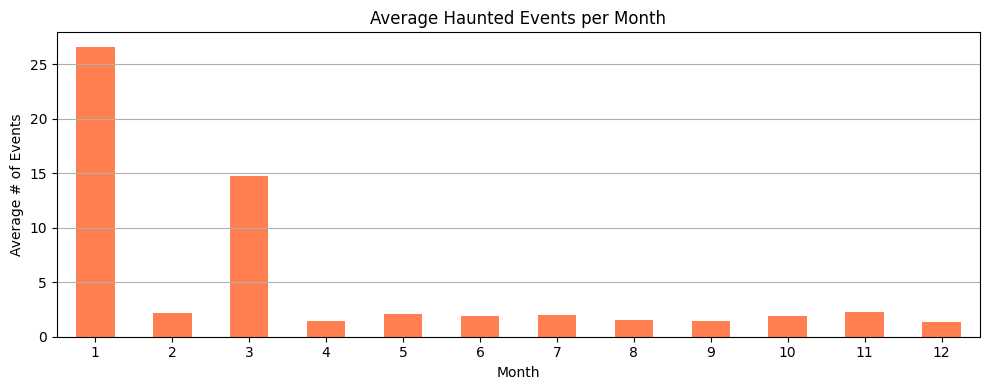

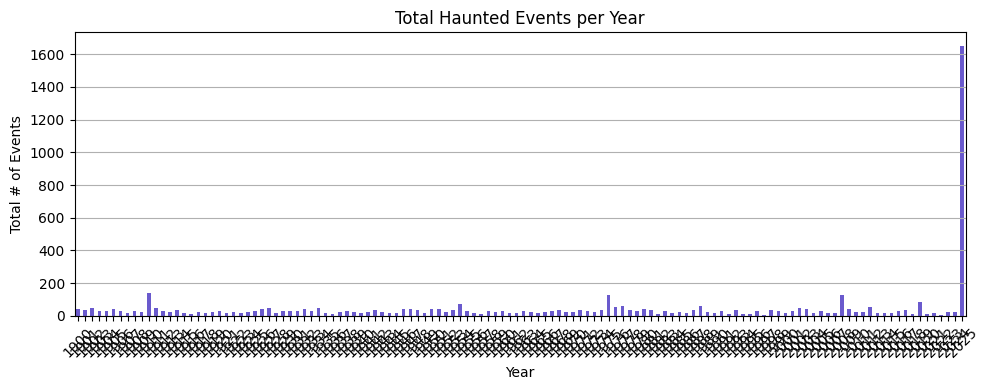

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load your processed calendar JSON data
with open("calendar_data.json", "r") as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

# Add year and month columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# --- INSIGHT 1: Average occurrences per month ---
monthly_avg = df.groupby('month')['count'].mean()

# --- INSIGHT 2: Total occurrences per year ---
yearly_total = df.groupby('year')['count'].sum()

# --- INSIGHT 3: Month with highest average, year with most events ---
max_month = monthly_avg.idxmax()
max_year = yearly_total.idxmax()

print(f"Month with highest average occurrences: {max_month} ({monthly_avg[max_month]:.2f} avg)")
print(f"Year with most total occurrences: {max_year} ({yearly_total[max_year]} total)")

# Load your generated calendar JSON
with open("calendar_data.json", "r") as f:
    data = json.load(f)

# Find the max number of events for a single day (i.e., one calendar box)
max_events_in_one_day = max(day["count"] for day in data)

print("Maximum events on a single day:", max_events_in_one_day)

# --- PLOT MONTHLY AVERAGE ---
plt.figure(figsize=(10, 4))
monthly_avg.plot(kind='bar', color='coral')
plt.title('Average Haunted Events per Month')
plt.xlabel('Month')
plt.ylabel('Average # of Events')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- PLOT YEARLY TOTALS ---
plt.figure(figsize=(10, 4))
yearly_total.plot(kind='bar', color='slateblue')
plt.title('Total Haunted Events per Year')
plt.xlabel('Year')
plt.ylabel('Total # of Events')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()